# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [2]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

/home/alba/anaconda3/envs/exoexo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [3]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

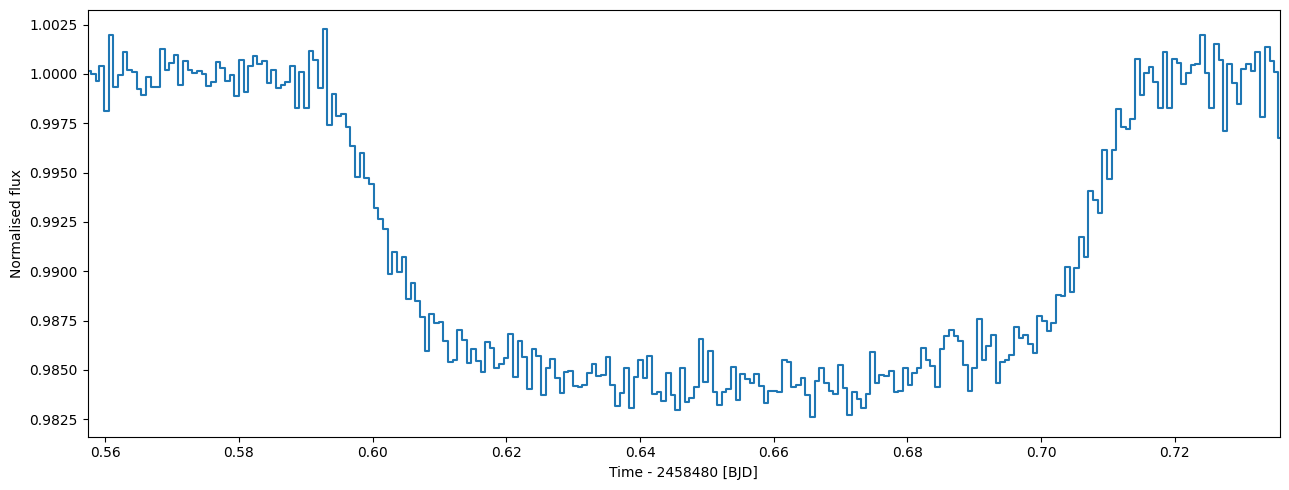

In [4]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [5]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [6]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [7]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

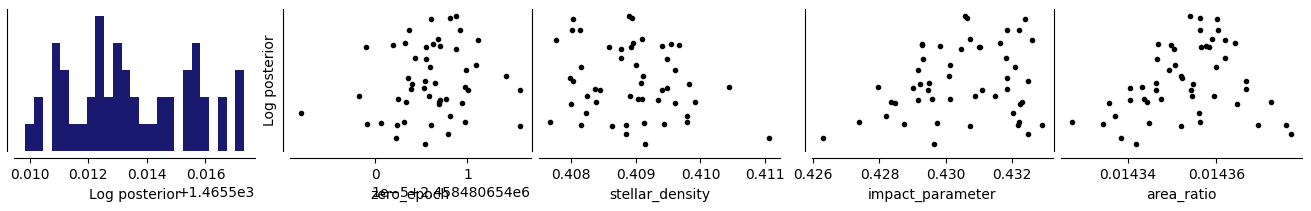

In [8]:
lpf.optimize_global(niter=500, npop=50)

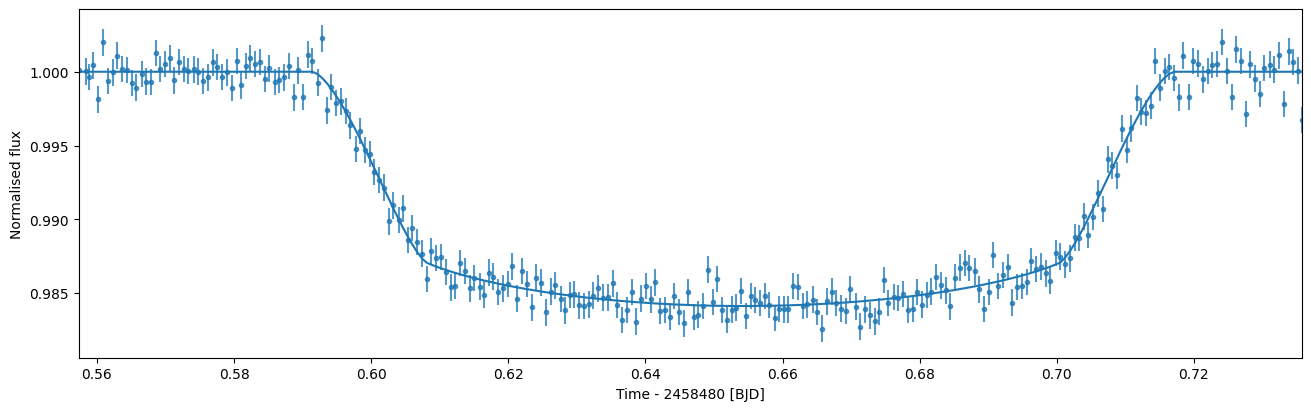

In [9]:
lpf.plot_light_curve();

In [10]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|██████████████████████████████| 2/2 [00:19<00:00,  9.77s/it]


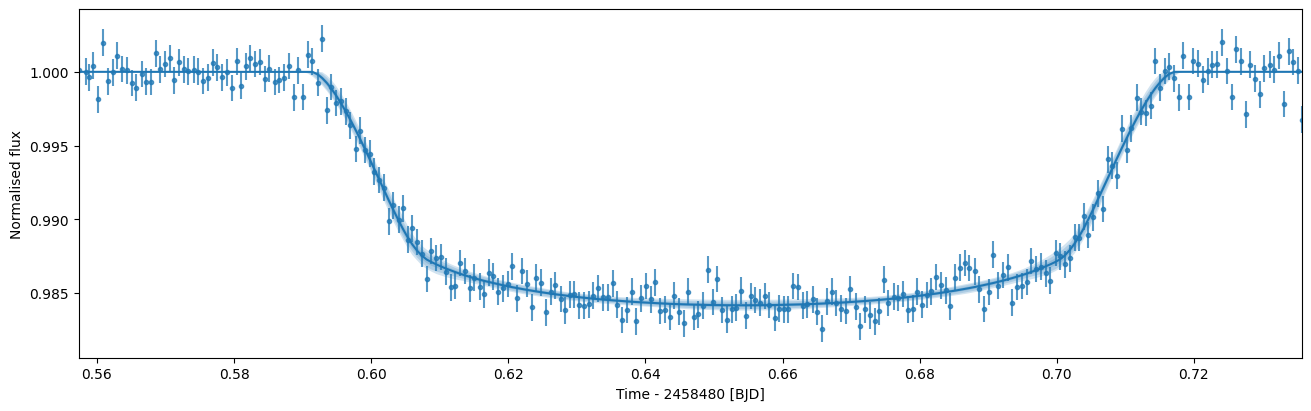

In [11]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

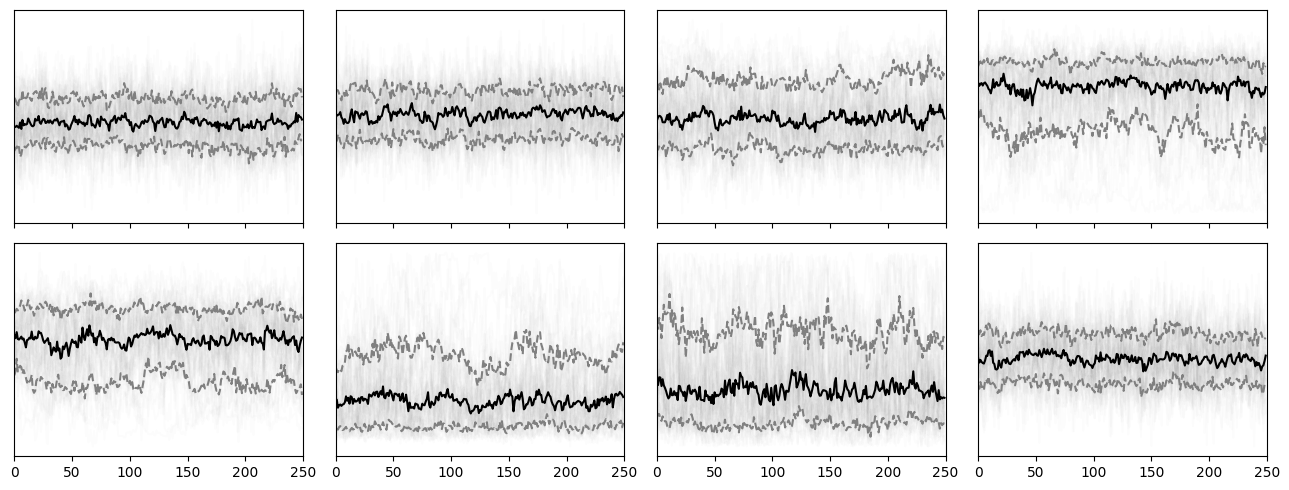

In [12]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [13]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [14]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

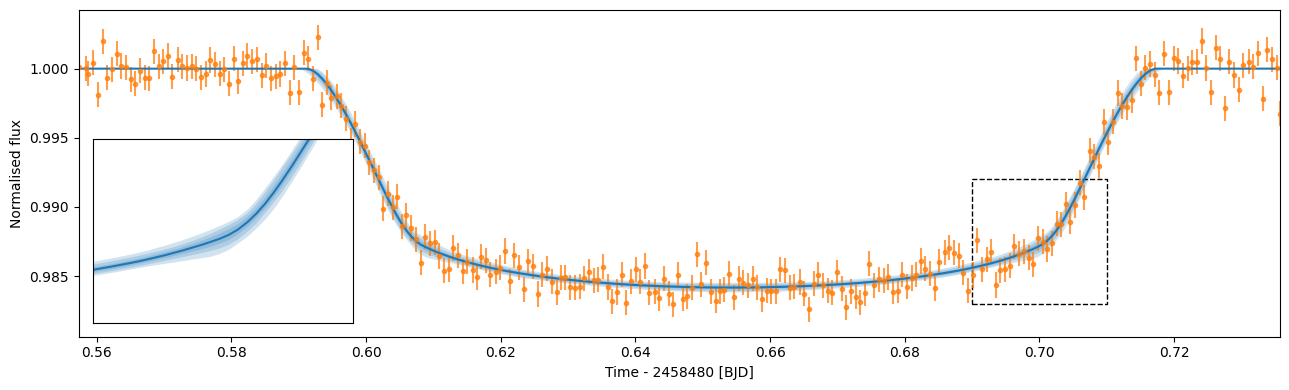

In [15]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [16]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4316,0.3483,0.0140,0.3096,0.3464,-3.0412,0.1182,3.0044,1.4535,0.1258,0.0945
std,1.6336e-04,1.0814e-09,0.0347,0.1102,0.0004,0.1889,0.2369,0.0194,0.0018,0.0803,0.0393,0.0010,0.0025
min,2.4585e+06,1.0914e+00,0.3298,0.0002,0.0127,0.0371,0.0009,-3.1068,0.1128,2.7488,1.3616,0.1221,0.0869
25%,2.4585e+06,1.0914e+00,0.4059,0.2901,0.0137,0.1639,0.1614,-3.0545,0.1170,2.9456,1.4245,0.1252,0.0926
50%,2.4585e+06,1.0914e+00,0.4285,0.3757,0.0140,0.2650,0.2892,-3.0414,0.1185,2.9993,1.4451,0.1258,0.0942
75%,2.4585e+06,1.0914e+00,0.4564,0.4298,0.0143,0.4125,0.4882,-3.0285,0.1196,3.0631,1.4758,0.1265,0.0963
max,2.4585e+06,1.0914e+00,0.5313,0.5709,0.0151,0.9997,0.9998,-2.9621,0.1228,3.2223,1.5707,0.1300,0.1010


<Axes: >

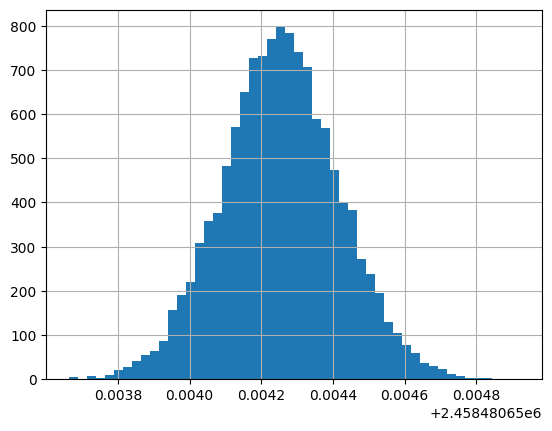

In [17]:
df.tc.hist(bins=50)

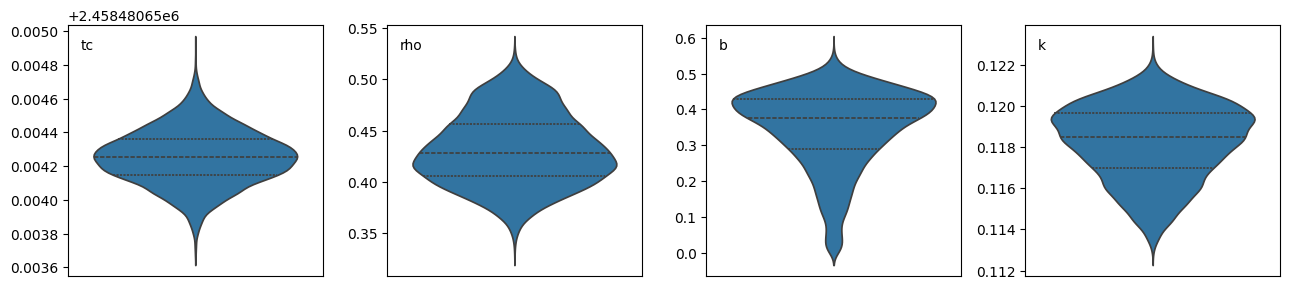

In [18]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

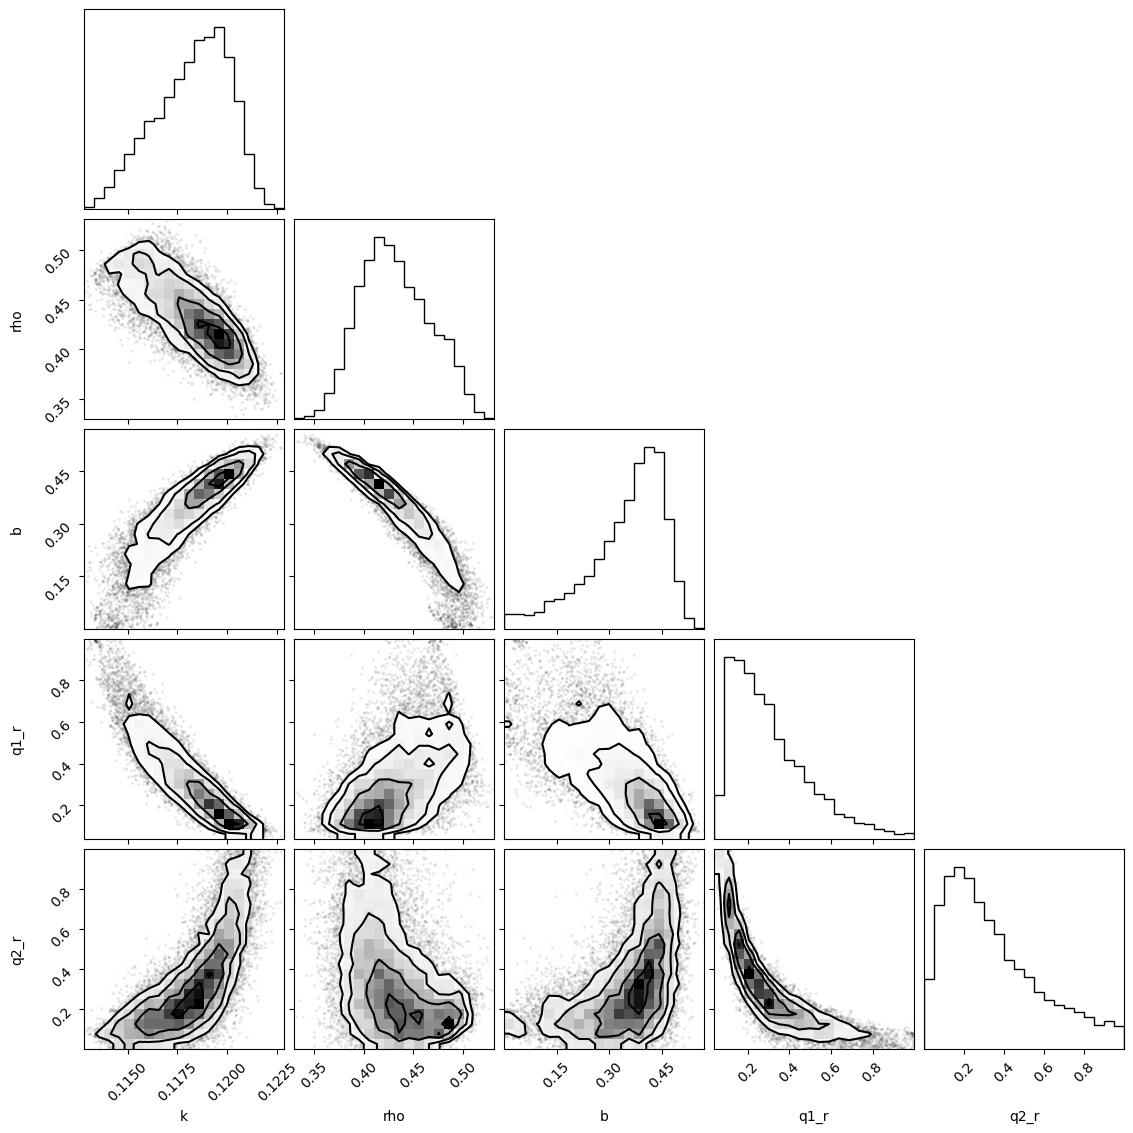

In [19]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

Stellar radius  : 1.657 R_sun  =  16.513 R_Jup
Median k (Rp/Rs): 0.11847
Planet radius   : 1.956 +0.027 / -0.038  R_Jup


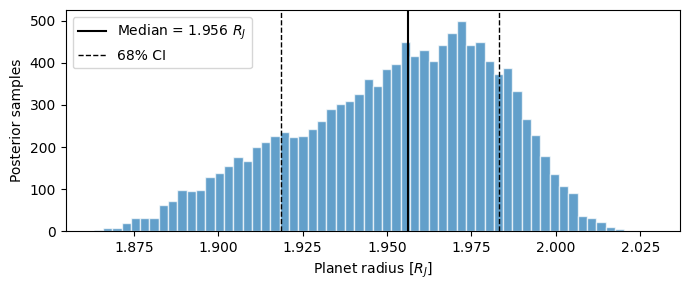

In [20]:
import numpy as np

# WASP-12 stellar radius from literature (Hebb et al. 2009 / Southworth et al.)
R_star_solar = 1.657        # stellar radius in solar radii
R_sun_jup    = 9.9658       # 1 R_sun = 9.9658 R_Jupiter

R_star_jup   = R_star_solar * R_sun_jup   # stellar radius in Jupiter radii

# k = Rp/Rs  — posterior samples
k_samples = df['k'].values

# Planet radius posterior in Jupiter radii
R_planet_jup = k_samples * R_star_jup

# Summary statistics
R_med  = np.median(R_planet_jup)
R_lo   = R_med - np.percentile(R_planet_jup, 16)
R_hi   = np.percentile(R_planet_jup, 84) - R_med

print(f"Stellar radius  : {R_star_solar:.3f} R_sun  =  {R_star_jup:.3f} R_Jup")
print(f"Median k (Rp/Rs): {np.median(k_samples):.5f}")
print(f"Planet radius   : {R_med:.3f} +{R_hi:.3f} / -{R_lo:.3f}  R_Jup")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(R_planet_jup, bins=60, color='C0', alpha=0.7, edgecolor='white')
ax.axvline(R_med, color='k', lw=1.5, label=f'Median = {R_med:.3f} $R_J$')
ax.axvline(R_med - R_lo, color='k', lw=1, ls='--')
ax.axvline(R_med + R_hi, color='k', lw=1, ls='--', label='68% CI')
ax.set_xlabel('Planet radius [$R_J$]')
ax.set_ylabel('Posterior samples')
ax.legend()
fig.tight_layout()


2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

Planet mass     : 1.404 ± 0.099 M_Jup
Planet radius   : 1.956 R_Jup  (median)
Bulk density    : 0.233 +0.021 / -0.018  g/cm³
Jupiter density : 1.326 g/cm³  (for reference)


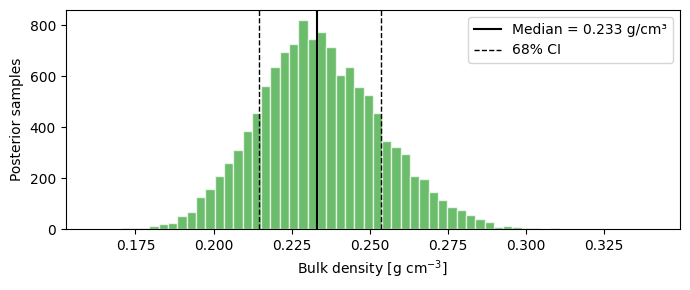

In [21]:
import numpy as np
import astropy.units as u
import astropy.constants as const

# ── Minimum mass from RV exercise (exercise 1 of the RV notebook)
# WASP-12b: Msini from published RVs
M_min_MJ   = 1.404          # planet minimum mass  [M_Jup]
M_min_err  = 0.099          # 1-sigma uncertainty  [M_Jup]

# Draw mass samples assuming Gaussian uncertainty
rng = np.random.default_rng(42)
n   = len(df['k'])
M_samples_MJ = rng.normal(M_min_MJ, M_min_err, n)

# ── Radius samples from Q1 (in Jupiter radii)
R_star_solar = 1.657
R_sun_jup    = 9.9658
R_star_jup   = R_star_solar * R_sun_jup
R_samples_jup = df['k'].values * R_star_jup   # R_planet in R_Jup

# ── Convert to SI for density calculation
M_samples_kg = M_samples_MJ * const.M_jup.value   # kg
R_samples_m  = R_samples_jup * const.R_jup.value  # m

# ── Bulk density  ρ = 3M / (4π R³)   [kg/m³]
rho_samples = (3 * M_samples_kg) / (4 * np.pi * R_samples_m**3)

# Convert to g/cm³
rho_gcm3 = rho_samples * 1e-3   # kg/m³ → g/cm³

rho_med = np.median(rho_gcm3)
rho_lo  = rho_med - np.percentile(rho_gcm3, 16)
rho_hi  = np.percentile(rho_gcm3, 84) - rho_med

print(f"Planet mass     : {M_min_MJ:.3f} ± {M_min_err:.3f} M_Jup")
print(f"Planet radius   : {np.median(R_samples_jup):.3f} R_Jup  (median)")
print(f"Bulk density    : {rho_med:.3f} +{rho_hi:.3f} / -{rho_lo:.3f}  g/cm³")
print(f"Jupiter density : 1.326 g/cm³  (for reference)")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(rho_gcm3, bins=60, color='C2', alpha=0.7, edgecolor='white')
ax.axvline(rho_med, color='k', lw=1.5, label=f'Median = {rho_med:.3f} g/cm³')
ax.axvline(rho_med - rho_lo, color='k', lw=1, ls='--')
ax.axvline(rho_med + rho_hi, color='k', lw=1, ls='--', label='68% CI')
ax.set_xlabel('Bulk density [g cm$^{-3}$]')
ax.set_ylabel('Posterior samples')
ax.legend()
fig.tight_layout()


3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- Radial velocity measure Mpsin(i) where i is the orbital inclination. Without knowing i, we can only calculate a minimum mass. A transit, however, requires the planet to pass directly in front of the star, so the inclination has to have values close to 90°.
A better way to estimate planetary properties would be to fit the RVs and photometry together. Fitting both datasets with a single mode that shares all common parameters, rather than combining the results of two independent fits.

4. What can you say about WASP-12b as a planet based on its orbital period, radius, mass, and bulk density?

- WASP-12b is a hot Jupiter: orbital period 1.09 d, radius 1.9 Rj, mass 1.4 Mj, and a very low bulk density 0.3 g/cm³. The extreme proximity to its host star drives intense irradiation and tidal effects, as we mentioned in the first exercise. This intense heating explains why its radius is so inflated compared to what standard cooling models predict. 

5. Compare the stellar density ($\rho$) estimated from the transit modeling to the theoretical stellar density for a WASP-12-like star.
- The transit model gives the stellar density through Kepler's third law. The stellar density makes sense when compared with what we would expect for a star similar to WASP-12, a slightly evolved F-type star, hotter and larger than the Sum, with a lower surface gravity and a lower mean density. 

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- The model is sensitive to certain combinations of multiple parameters. A clear example is how the impact parameter b and the radius ratio k move in opposite directions. If the transit is more grazing (higher b), it blocks less light, which can look similar to having a slightly smaller planet (lower k). In practice this means two things: first, quoting uncertainties for each parameter separately can give a misleading impression of how well they are actually known; and second, whenever we propagate uncertainties, we need to use the full joint posterior instead of treating the parameters as if they were independent.

---
<center>&copy;2026 Hannu Parviainen</center>